In [ ]:
import glob
import json
import math
import os
from pathlib import Path

import joblib
from moviepy import VideoFileClip
from sklearn.metrics.pairwise import cosine_similarity
from transformers import PeAudioVideoModel, PeAudioVideoProcessor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PeAudioVideoModel.from_pretrained("facebook/pe-av-large")
processor = PeAudioVideoProcessor.from_pretrained("facebook/pe-av-large")
# model = PeAudioVideoModel.from_pretrained("facebook/pe-av-large-16-frame")
# processor = PeAudioVideoProcessor.from_pretrained("facebook/pe-av-large-16-frame")

model = model.to(device)

In [ ]:
# How to get word timing segments from the JSON output of WhisperX

captions_fp = "Nixon_I_Am_the_Wife.json"

captions_type = "english"

with open(captions_fp, "r", encoding="utf-8") as cap_file:
    captions_json = json.load(cap_file)

# Better to use the force-aligned timings -- much better!
word_segments = captions_json["segments"]

In [ ]:
# How to get word timing segments from a VTT caption file

import webvtt

captions_type = "translation"

captions_fp = f"hashitomi.{captions_type}.vtt"


def get_sec(time_str):
    """Get seconds from time."""
    h, m, s = time_str.split(":")
    return float(h) * 3600 + float(m) * 60 + float(s)


word_segments = []

for caption in webvtt.read(captions_fp):
    word_segments.append(
        {
            "start": get_sec(caption.start),
            "end": get_sec(caption.end),
            "text": caption.text,
        }
    )

In [ ]:
movie_fp = "Nixon_I_Am_the_Wife.mp4"

CLIP_DURATION_SECS = 10
CLIP_INTERVAL_SECS = 5

movie_stem = f"{Path(movie_fp).stem}_{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}"

In [ ]:
# Slice video into separate files for audio, video, text (captions) shingles
def save_av_shingles(movie_fp, movie_stem, word_segments):

    os.makedirs(f"{movie_stem}/", exist_ok=True)

    clip = VideoFileClip(movie_fp)

    for shingle_start in range(0, math.ceil(clip.duration), CLIP_INTERVAL_SECS):
        shingle_end = min(clip.duration, shingle_start + CLIP_DURATION_SECS)

        words_in_shingle = []
        for word in word_segments:
            if (
                (word["start"] >= shingle_start and word["end"] <= shingle_end)
                or (
                    word["start"] < shingle_start
                    and word["end"] > shingle_start
                    and word["end"] <= shingle_end
                )
                or (
                    word["start"] >= shingle_start
                    and word["start"] < shingle_end
                    and word["end"] > shingle_end
                )
            ):
                words_in_shingle.append(word["text"])

        with open(
            os.path.join(
                movie_stem,
                f"{movie_stem}.{str(shingle_start).zfill(4)}-{str(int(shingle_end)).zfill(4)}.txt",
            ),
            "w",
            encoding="utf-8",
        ) as shingle_textfile:
            shingle_textfile.write(" ".join(words_in_shingle))

        subclip_video_fn = f"{movie_stem}.{str(shingle_start).zfill(4)}-{str(int(shingle_end)).zfill(4)}{Path(movie_fp).suffix}"
        if os.path.exists(os.path.join(movie_stem, subclip_video_fn)):
            # Skip processing the shingle if a video excerpt for it already exists
            print("Skipping rest of", os.path.join(movie_stem, subclip_video_fn))
            continue

        subclip = clip.subclipped(shingle_start, shingle_end)

        subclip.write_videofile(os.path.join(movie_stem, subclip_video_fn))

        subclip_audio_fn = f"{movie_stem}.{str(shingle_start).zfill(4)}-{str(int(shingle_end)).zfill(4)}.mp3"
        subclip.audio.write_audiofile(os.path.join(movie_stem, subclip_audio_fn))


save_av_shingles(movie_fp, movie_stem, word_segments)


In [ ]:
# How to embed a short clip (video content only) to query against other PE-AV embeddings
inputs = processor(
    videos=["Kata-Ona_mawari_kaeshi_Front.mp4"],
    text=["feminine circlet point"],
    return_tensors="pt",
    padding=True,
)
with torch.inference_mode(), torch.autocast(device.type, dtype=torch.bfloat16):
    example_outputs = model(**inputs.to(device), return_loss=True)

query_video_embed = example_outputs.video_embeds.cpu().float()

In [ ]:
# Brute-force sliding window comparison of a short clip's video embedding against a series of
# shingles of a longer video (again, comparing video embeddings only -- although swapping in
# text and image embeddings is straightforward because they're all in the same vector space)

movie_ext = Path(movie_fp).suffix

BATCH_SIZE = 4

visual_similarities = []

video_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*{movie_ext}"))
text_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*.txt"))
audio_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*.mp3"))

for batch_start in range(0, len(video_files), BATCH_SIZE):
    batch_end = min(len(video_files), batch_start + BATCH_SIZE)

    batch_texts = []
    for text_file in text_files[batch_start:batch_end]:
        with open(text_file, "r", encoding="utf-8") as tfile:
            batch_texts.append(tfile.read())

    print(
        video_files[batch_start:batch_end],
        batch_texts,
        audio_files[batch_start:batch_end],
    )

    # Process inputs and get embeddings
    inputs = processor(
        videos=video_files[batch_start:batch_end],
        text=batch_texts,
        audio=audio_files[batch_start:batch_end],
        return_tensors="pt",
        padding=True,
    )

    with torch.inference_mode(), torch.autocast(device.type, dtype=torch.bfloat16):
        outputs = model(**inputs.to(device), return_loss=True)

    for o in range(BATCH_SIZE):
        video_index = batch_start + o
        if video_index >= len(video_files):
            break

        video_fn = video_files[video_index]
        shingle_start, shingle_end = [
            int(item) for item in video_fn.split(".")[-2].split("-")
        ]

        # Use outputs.audio_embeds[0]... if you want to quantify visual-audio similarity
        visual_sim = cosine_similarity(
            [outputs.video_embeds[o].cpu().float()], query_video_embed
        )
        visual_similarities.append(visual_sim[0])

        visual_embed_fn = f"{movie_stem}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}.{captions_type}.{shingle_start}_{shingle_end}.visual.pkl"
        print(visual_embed_fn)

        joblib.dump(
            outputs.video_embeds[0].cpu().float(),
            os.path.join(movie_stem, visual_embed_fn),
            compress=3,
        )

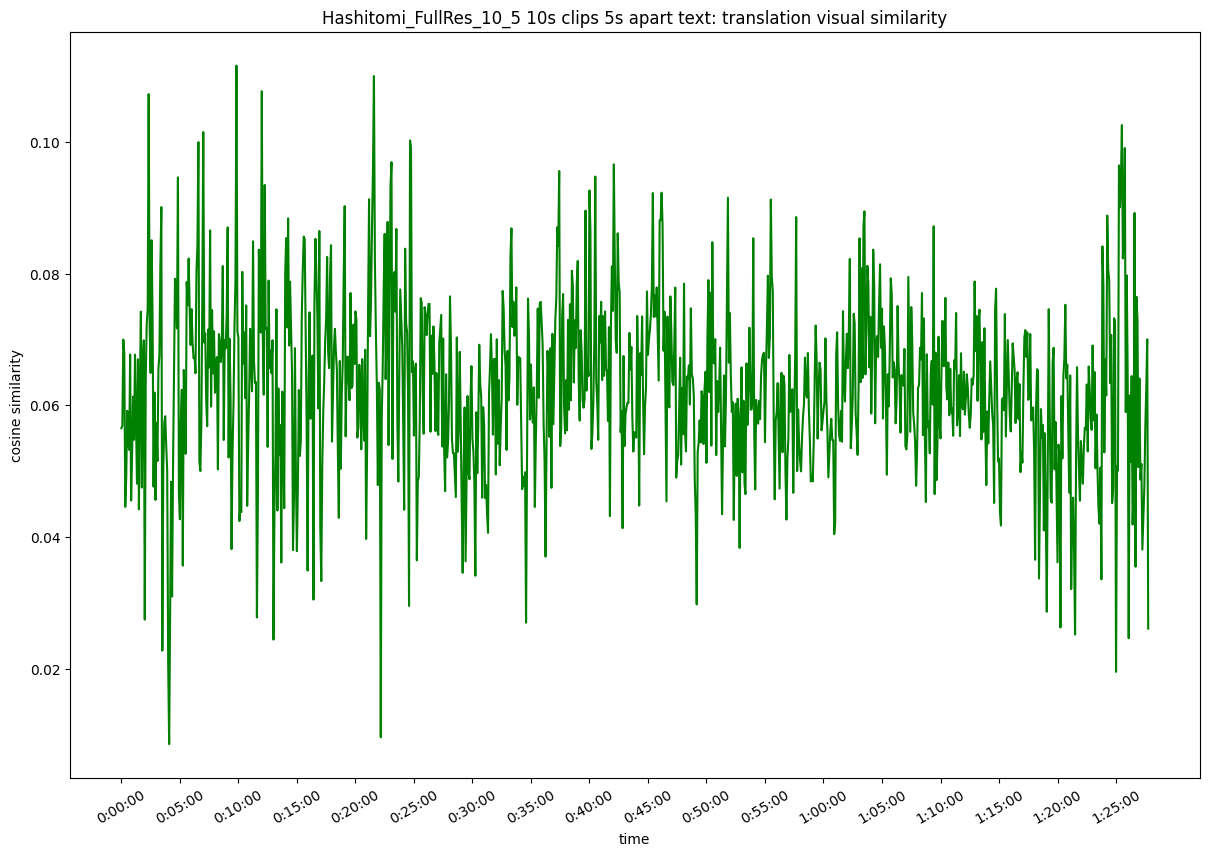

In [ ]:
# Plot visual similarities of query video against longer video

import matplotlib.pyplot as plt
from datetime import timedelta

vis_sim_secs = [5 * x for x in range(len(visual_similarities))]

fig = plt.figure(figsize=(12, 8), dpi=100)

ax = plt.gca()
time_data = [str(timedelta(seconds=int(s))) for s in vis_sim_secs]

plt.plot(time_data, visual_similarities, color="green")

plt.tight_layout()
plt.xticks(ticks=list(range(0, len(vis_sim_secs), 60)), rotation=30)

plt.title(
    f"{movie_stem} {CLIP_DURATION_SECS}s clips {CLIP_INTERVAL_SECS}s apart text: {captions_type} visual similarity"
)
plt.xlabel("time")
plt.ylabel("cosine similarity")
plt.show()

In [ ]:
import numpy as np
import time

best_index = np.argmax(visual_similarities)
best_match_time = time.strftime("%H:%M:%S", time.gmtime(best_index * 5))
print(f"best match at time {best_match_time}")

'00:09:50'

In [ ]:
# Cross-compare the embedded modalities for the same video (to itself) at time points defined by the
#  overlapping "shingles"
# Some available comparisons:
# - av_cosine: cosine similarity of audio embeddings and visual embeddings
# - at_cosine: cosine similarity of audio embeddings and audio-optimized text embeddings
# - vt_cosine: cosine similarity of visual embeddings and video-optimized text embeddings
# - avt_cosine: cosine similarity of joint audiovisual embeddings and joint AV-optimized text embeddings

# movie_stem = Path(movie_fp).stem # Should get from above
movie_ext = Path(movie_fp).suffix

BATCH_SIZE = 4

video_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*{movie_ext}"))
text_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*.txt"))
audio_files = sorted(glob.glob(f"{movie_stem}/{movie_stem}*.mp3"))

shingle_av_cosine = {}
shingle_at_cosine = {}
shingle_vt_cosine = {}
shingle_avt_cosine = {}

for batch_start in range(0, len(video_files), BATCH_SIZE):
    batch_end = min(len(video_files), batch_start + BATCH_SIZE)

    batch_texts = []
    for text_file in text_files[batch_start:batch_end]:
        with open(text_file, "r", encoding="utf-8") as tfile:
            batch_texts.append(tfile.read())

    print(
        video_files[batch_start:batch_end],
        batch_texts,
        audio_files[batch_start:batch_end],
    )

    # Process inputs and get embeddings
    inputs = processor(
        videos=video_files[batch_start:batch_end],
        text=batch_texts,
        audio=audio_files[batch_start:batch_end],
        return_tensors="pt",
        padding=True,
        # videos=video_files, text=None, audio=audio_files, return_tensors="pt", padding=True
    )

    with torch.inference_mode(), torch.autocast(device.type, dtype=torch.bfloat16):
        outputs = model(**inputs.to(device), return_loss=True)

    for o in range(BATCH_SIZE):
        video_index = batch_start + o
        if video_index >= len(video_files):
            break

        video_fn = video_files[video_index]
        shingle_start, shingle_end = [
            int(item) for item in video_fn.split(".")[-2].split("-")
        ]

        shingle_av_cosine[(shingle_start + shingle_end) / 2] = cosine_similarity(
            [outputs.audio_embeds[o].cpu().float()],
            [outputs.video_embeds[o].cpu().float()],
        )
        if batch_texts[o] == "":
            shingle_at_cosine[(shingle_start + shingle_end) / 2] = [[0]]
            shingle_vt_cosine[(shingle_start + shingle_end) / 2] = [[0]]
            shingle_avt_cosine[(shingle_start + shingle_end) / 2] = [[0]]
        else:
            shingle_at_cosine[(shingle_start + shingle_end) / 2] = cosine_similarity(
                [outputs.text_audio_embeds[o].cpu().float()],
                [outputs.audio_embeds[0].cpu().float()],
            )
            shingle_vt_cosine[(shingle_start + shingle_end) / 2] = cosine_similarity(
                [outputs.text_video_embeds[o].cpu().float()],
                [outputs.video_embeds[0].cpu().float()],
            )
            shingle_avt_cosine[(shingle_start + shingle_end) / 2] = cosine_similarity(
                [outputs.audio_plus_text_embeds[o].cpu().float()],
                [outputs.video_plus_text_embeds[0].cpu().float()],
            )

In [ ]:
# Save cross-comparison "perception" data to a file

perception_data = {
    "avsim": shingle_av_cosine,
    "atsim": shingle_at_cosine,
    "vtsim": shingle_vt_cosine,
    "avt_sim": shingle_avt_cosine,
    "word_segments": word_segments,
}
outfn = f"{movie_fp}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}.{captions_type}.pkl"
joblib.dump(perception_data, outfn, compress=3)

In [ ]:
# Load saved cross-comparison "perception" data

outfn = f"{movie_fp}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}.{captions_type}.pkl"
perception_data = joblib.load(outfn)

shingle_av_cosine = perception_data["avsim"]
shingle_at_cosine = perception_data["atsim"]
shingle_vt_cosine = perception_data["vtsim"]
shingle_avt_cosine = perception_data["avt_sim"]

In [ ]:
# Display the video, for comparison to the time-series plot of modality similarities

from IPython.display import Video

Video("Nixon_Kim_Met_tOM3lUImsZA.mp4")

Nixon_Kim_Met_tOM3lUImsZA_20_10.20_10.png


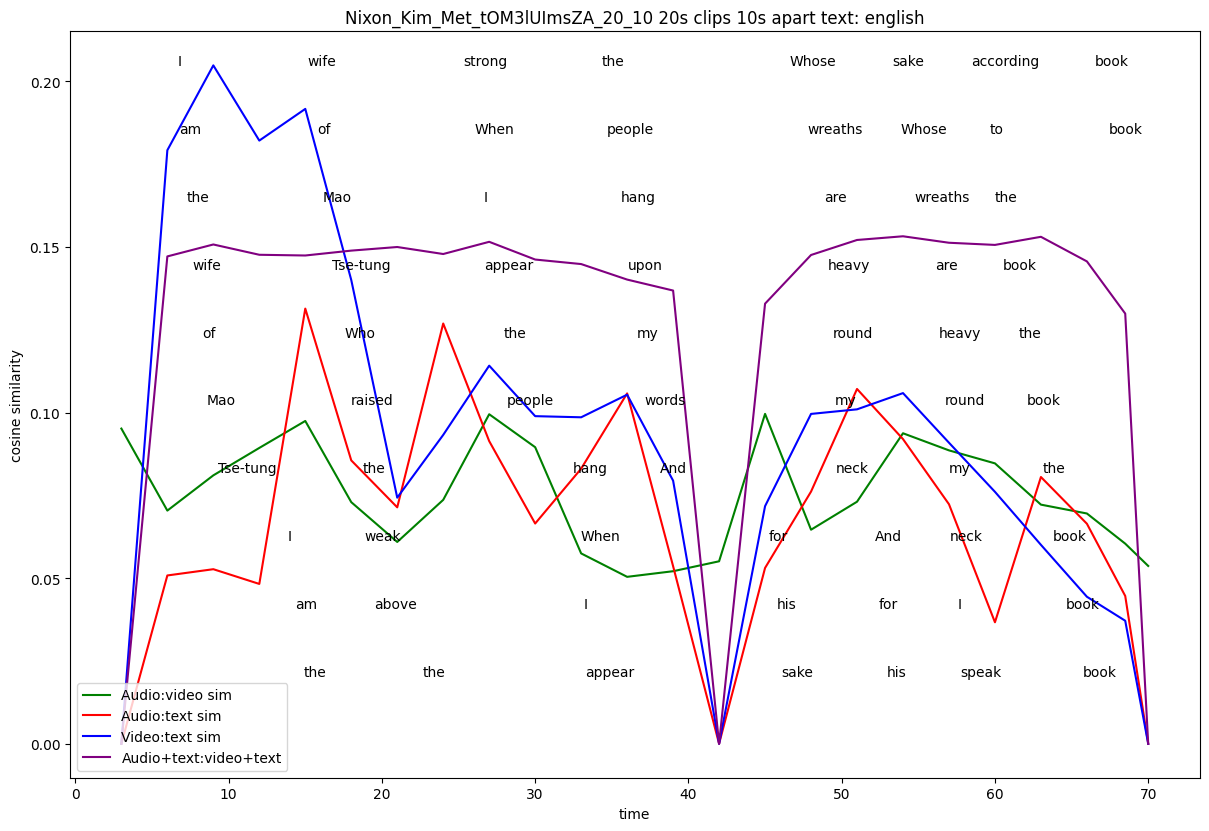

In [ ]:
# Plot similarities among modalities for the same video

import matplotlib.pyplot as plt
from datetime import timedelta

TEXT_ROWS = 10

shingle_av_x = list(shingle_av_cosine.keys())
shingle_av_y = [float(val[0][0]) for val in shingle_av_cosine.values()]
shingle_at_x = list(shingle_at_cosine.keys())
shingle_at_y = [float(val[0][0]) for val in shingle_at_cosine.values()]
shingle_vt_x = list(shingle_vt_cosine.keys())
shingle_vt_y = [float(val[0][0]) for val in shingle_vt_cosine.values()]
shingle_avt_x = list(shingle_avt_cosine.keys())
shingle_avt_y = [float(val[0][0]) for val in shingle_avt_cosine.values()]

text_x = [word["start"] for word in word_segments]
ymin = min(shingle_av_y + shingle_at_y + shingle_vt_y + shingle_avt_y)
ymax = max(shingle_av_y + shingle_at_y + shingle_vt_y + shingle_avt_y)

text_y_spacing = (ymax - ymin) / TEXT_ROWS
text_y = []

for w, word in enumerate(word_segments):
    text_y.append(((w % TEXT_ROWS) * text_y_spacing) + ymin)

# For long videos (this only really affects the X-axis granularity)
# time_data = [str(timedelta(seconds=int(s))) for s in shingle_av_x]
# For short videos
time_data = shingle_av_x

fig = plt.figure(figsize=(12, 8), dpi=100)

ax = plt.gca()

plt.plot(time_data, shingle_av_y, color="green", label="Audio:video sim")
plt.plot(time_data, shingle_at_y, color="red", label="Audio:text sim")
plt.plot(time_data, shingle_vt_y, color="blue", label="Video:text sim")
plt.plot(time_data, shingle_avt_y, color="purple", label="Audio+text:video+text")

# For long videos only
# plt.xticks(ticks = list(range(0,len(shingle_av_x),60)),rotation=30)
plt.tight_layout()

plt.title(
    f"{movie_stem} {CLIP_DURATION_SECS}s clips {CLIP_INTERVAL_SECS}s apart text: {captions_type}"
)
plt.xlabel("time")
plt.ylabel("cosine similarity")
ax.legend(loc="lower left")

for w, word in enumerate(word_segments):
    ax.text(
        float(word["start"]),
        float(ymax - ((w % TEXT_ROWS) * text_y_spacing)),
        word["text"],
    )
print(f"{movie_stem}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}.png")

fig.savefig(
    f"{movie_stem}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}_{captions_type}.png",
    dpi=300,
    bbox_inches="tight",
)


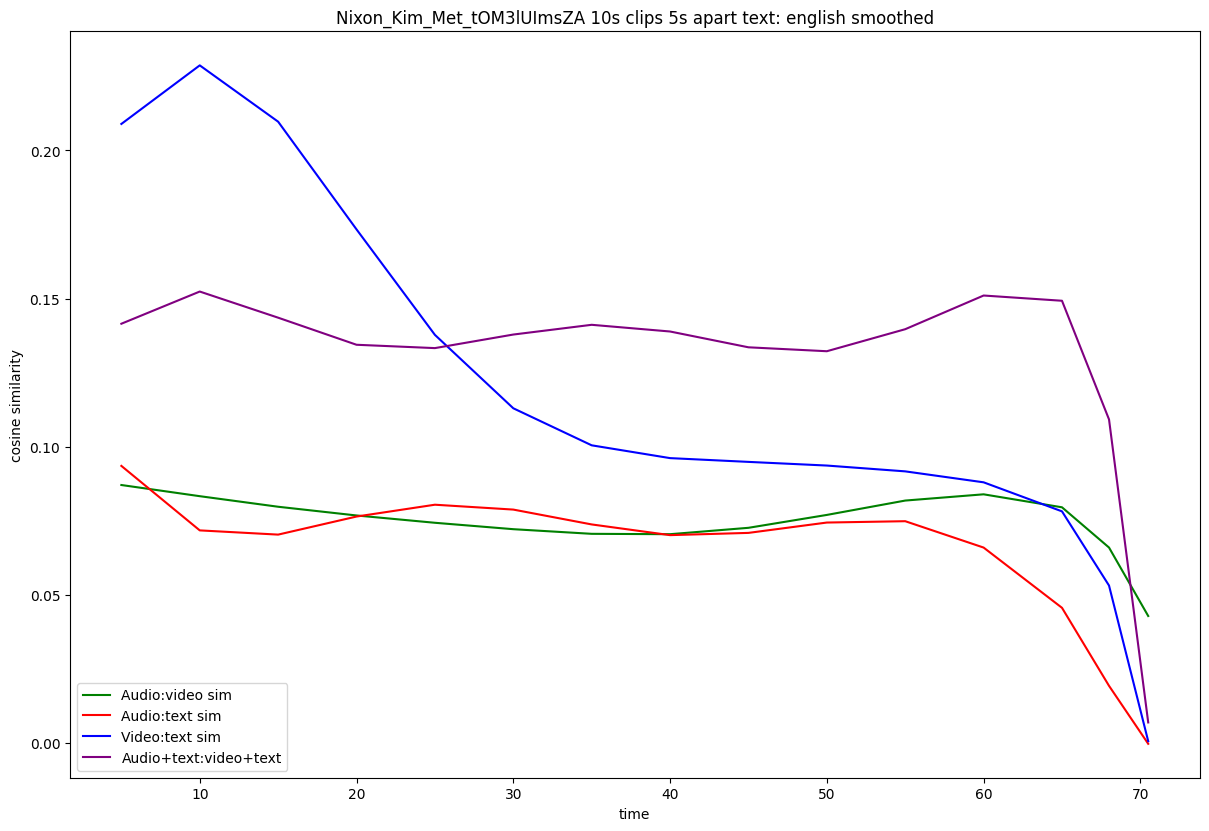

ValueError: x and y must have same first dimension, but have shapes (15,) and (500,)

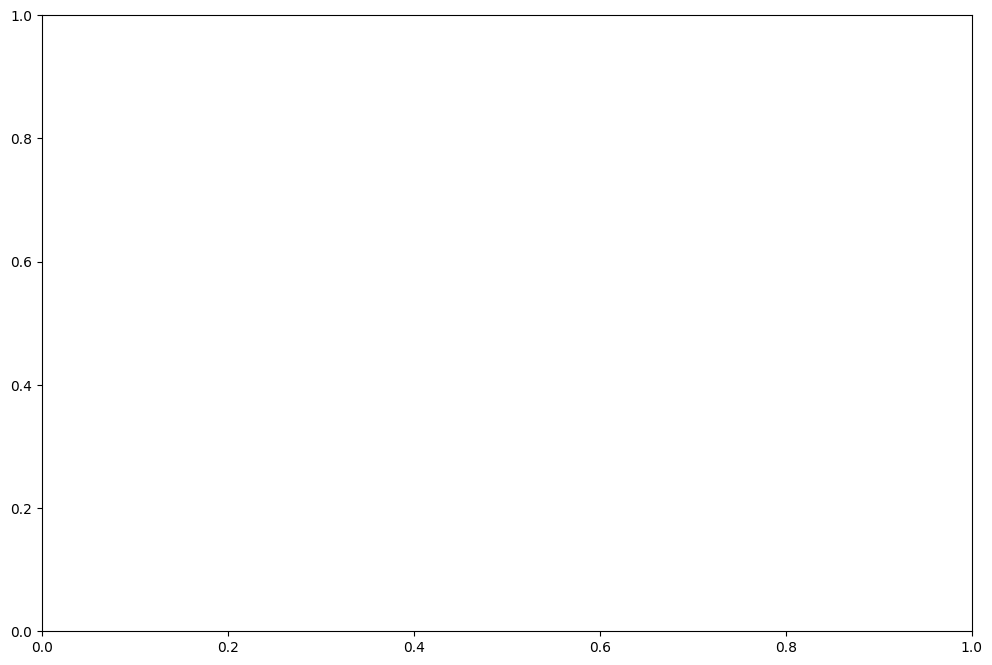

In [ ]:
# Plot smoothed cross-modal similarity curves

import numpy as np
from tsmoothie.smoother import GaussianSmoother


def get_ma_and_gaussian_smoothed(y_values):

    # FRAMES_TARGET = 1800
    # MAX_SAMPLE_GAP = 240
    WINDOW_SIZE = 500

    # sample_gap = min(MAX_SAMPLE_GAP, max(1, round(len(y_values) / FRAMES_TARGET)))

    midpt = int(WINDOW_SIZE / 2)
    step = 1 / (midpt + 1)
    weights = [i * step for i in range(1, midpt + 2)]
    weights.extend(list(reversed(weights))[1:])

    weights = np.ones(WINDOW_SIZE) / WINDOW_SIZE

    ma_y_values = np.convolve(y_values, weights, mode="same")

    smoother = GaussianSmoother(n_knots=6, sigma=0.1)
    smoother.smooth(y_values)
    gaussian_y_values = smoother.smooth_data[0]

    return ma_y_values, gaussian_y_values


shingle_av_ma, shingle_av_gaussian = get_ma_and_gaussian_smoothed(shingle_av_y)
shingle_at_ma, shingle_at_gaussian = get_ma_and_gaussian_smoothed(shingle_at_y)
shingle_vt_ma, shingle_vt_gaussian = get_ma_and_gaussian_smoothed(shingle_vt_y)
shingle_avt_ma, shingle_avt_gaussian = get_ma_and_gaussian_smoothed(shingle_avt_y)

fig = plt.figure(figsize=(12, 8), dpi=100)

ax = plt.gca()

plt.plot(time_data, shingle_av_gaussian, color="green", label="Audio:video sim")
plt.plot(time_data, shingle_at_gaussian, color="red", label="Audio:text sim")
plt.plot(time_data, shingle_vt_gaussian, color="blue", label="Video:text sim")
plt.plot(time_data, shingle_avt_gaussian, color="purple", label="Audio+text:video+text")

# For long videos only
# plt.xticks(ticks = list(range(0,len(shingle_av_x),60)),rotation=30)
plt.tight_layout()

plt.title(
    f"{movie_stem} {CLIP_DURATION_SECS}s clips {CLIP_INTERVAL_SECS}s apart text: {captions_type} smoothed"
)
plt.xlabel("time")
plt.ylabel("cosine similarity")
ax.legend(loc="lower left")

fig.savefig(
    f"{movie_stem}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}_{captions_type}_smoothed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


fig = plt.figure(figsize=(12, 8), dpi=100)

ax = plt.gca()

plt.plot(time_data, shingle_av_ma, color="green", label="Audio:video sim")
plt.plot(time_data, shingle_at_ma, color="red", label="Audio:text sim")
plt.plot(time_data, shingle_vt_ma, color="blue", label="Video:text sim")
plt.plot(time_data, shingle_avt_ma, color="purple", label="Audio+text:video+text")

# For long videos only
# plt.xticks(ticks = list(range(0,len(shingle_av_x),60)),rotation=30)
plt.tight_layout()

plt.title(
    f"{movie_stem} {CLIP_DURATION_SECS}s clips {CLIP_INTERVAL_SECS}s apart text: {captions_type} moving average"
)
plt.xlabel("time")
plt.ylabel("cosine similarity")
ax.legend(loc="lower left")

fig.savefig(
    f"{movie_stem}.{CLIP_DURATION_SECS}_{CLIP_INTERVAL_SECS}_{captions_type}_ma.png",
    dpi=300,
    bbox_inches="tight",
)